# Pipeline 2: Social Media Referrals (6 Prediction Targets)

**New Dawn Safehouse Management System — ML Pipeline**

---

## Table of Contents
1. Business Understanding & Problem Definition
2. Data Understanding & Exploration
3. Data Preparation & Feature Engineering
4. Modelling — 6 Regression Models (Ch. 6–9)
5. Hyperparameter Tuning (Ch. 11)
6. Model Evaluation & Feature Importance (Ch. 12–13)
7. Lookup Table Generation
8. Deployment — CSV Output & Web Integration (Ch. 15)

## 1. Business Understanding & Problem Definition

New Dawn's social media team publishes posts across Instagram, Facebook, TikTok, LinkedIn, Twitter, and WhatsApp. Each post has controllable features (platform, media type, CTA type, content topic, etc.) and measurable outcomes.

### Goal
Build **6 regression models** that predict post-level outcomes from controllable features:
1. `donation_referrals` — number of donations traced back to this post
2. `estimated_donation_value_php` — total PHP attributed to this post
3. `forwards` — shares/forwards
4. `profile_visits` — profile visits driven by this post
5. `engagement_rate` — likes + comments + shares / reach
6. `impressions` — total views

The predictions power the **Social Media Editor** page's real-time prediction cards, updating as the author changes post attributes.

### Success Criteria
- Positive R² on cross-validation for all 6 targets
- Reasonable RMSE relative to target standard deviation
- Lookup table ≤ 50,000 rows for fast API lookups

## 2. Data Understanding & Exploration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')

posts = pd.read_csv('../lighthouse_csv_v7/social_media_posts.csv')
print(f'Social media posts: {posts.shape}')
print(f'Columns: {posts.columns.tolist()}')
posts.head(3)

Social media posts: (812, 39)
Columns: ['post_id', 'platform', 'platform_post_id', 'post_url', 'created_at', 'day_of_week', 'post_hour', 'post_type', 'media_type', 'caption', 'hashtags', 'num_hashtags', 'mentions_count', 'has_call_to_action', 'call_to_action_type', 'content_topic', 'sentiment_tone', 'caption_length', 'features_resident_story', 'campaign_name', 'is_boosted', 'boost_budget_php', 'impressions', 'reach', 'likes', 'comments', 'shares', 'saves', 'click_throughs', 'video_views', 'engagement_rate', 'profile_visits', 'donation_referrals', 'estimated_donation_value_php', 'follower_count_at_post', 'watch_time_seconds', 'avg_view_duration_seconds', 'subscriber_count_at_post', 'forwards']


,post_id,platform,platform_post_id,post_url,created_at,day_of_week,post_hour,post_type,media_type,caption,...,video_views,engagement_rate,profile_visits,donation_referrals,estimated_donation_value_php,follower_count_at_post,watch_time_seconds,avg_view_duration_seconds,subscriber_count_at_post,forwards
0,318,WhatsApp,wa_4293211912553134,https://whatsapp.com/channel/lighthouse_ph/429...,2023-01-05 18:52:00,Thursday,18,FundraisingAppeal,Text,"This is hard to ask, but our reserve is gone. ...",...,NaN,0.1105,21,10,21473.25,1522,NaN,NaN,NaN,50.0
1,529,Instagram,ig_5129900136072862,https://instagram.com/p/sYhZp-0AvhH,2023-01-06 11:30:00,Friday,11,EducationalContent,Photo,What does freedom mean to a trafficking surviv...,...,NaN,0.1745,335,2,4708.45,1833,NaN,NaN,NaN,NaN
2,86,LinkedIn,li_2326736034499294,https://linkedin.com/feed/update/urn:li:activi...,2023-01-08 10:14:00,Sunday,10,EventPromotion,Text,SAVE THE DATE! Join us on January 21 for Fundr...,...,NaN,0.1411,8,0,0.00,457,NaN,NaN,NaN,NaN


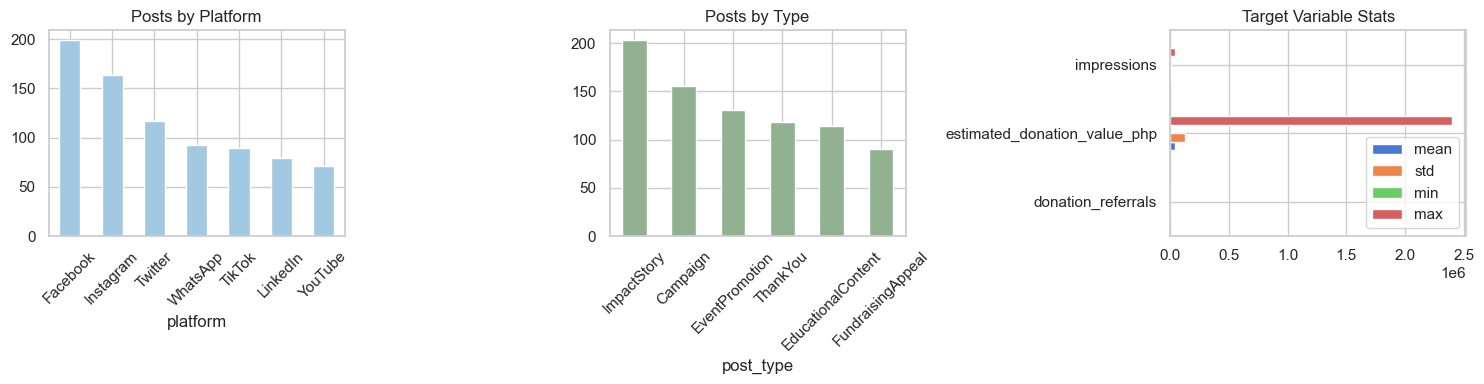

In [2]:
# Platform & post type distributions
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

posts['platform'].value_counts().plot.bar(ax=axes[0], color='#A2C9E1')
axes[0].set_title('Posts by Platform')
axes[0].tick_params(axis='x', rotation=45)

posts['post_type'].value_counts().plot.bar(ax=axes[1], color='#91B191')
axes[1].set_title('Posts by Type')
axes[1].tick_params(axis='x', rotation=45)

targets = ['donation_referrals', 'estimated_donation_value_php', 'impressions']
for t in targets:
    posts[t] = pd.to_numeric(posts[t], errors='coerce')
posts[targets].describe().T[['mean', 'std', 'min', 'max']].plot.barh(ax=axes[2])
axes[2].set_title('Target Variable Stats')

plt.tight_layout()
plt.show()

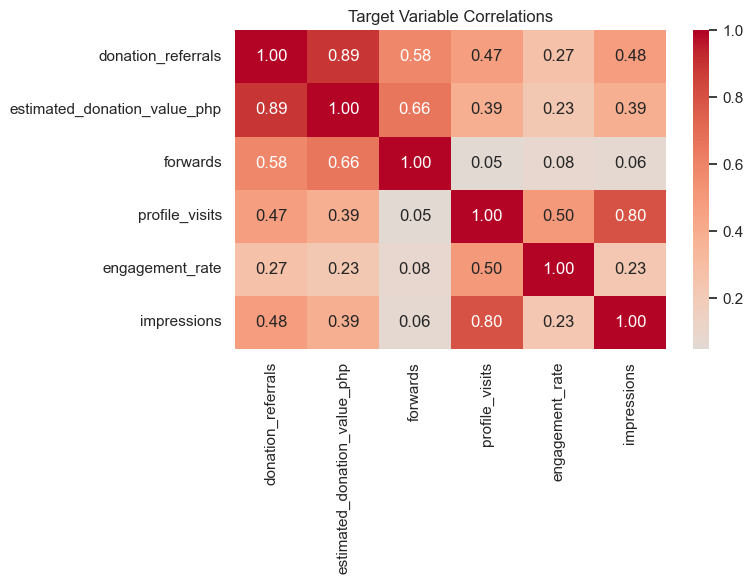

In [3]:
# Target correlations
target_cols = ['donation_referrals', 'estimated_donation_value_php', 'forwards',
               'profile_visits', 'engagement_rate', 'impressions']
for c in target_cols:
    posts[c] = pd.to_numeric(posts[c], errors='coerce').fillna(0)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(posts[target_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax)
ax.set_title('Target Variable Correlations')
plt.tight_layout()
plt.show()

## 3. Data Preparation & Feature Engineering

We use the pipeline module's preparation functions:
- Boolean columns → 'Yes'/'No' strings for consistent encoding
- Categorical features → one-hot encoded
- Numeric features: `caption_length`, `num_hashtags`, `mentions_count`, `boost_budget_php`, `post_hour`

In [4]:
import sys, os
sys.path.insert(0, os.path.abspath('.'))
from pipelines.social_media_referrals import prepare_data, encode_features, TARGETS, CAT_COLS, NUM_COLS

df = prepare_data(posts)
X_encoded, feature_names = encode_features(df)

print(f'Prepared dataset: {df.shape}')
print(f'Encoded features: {X_encoded.shape}')
print(f'\nCategorical columns: {CAT_COLS}')
print(f'Numeric columns: {NUM_COLS}')
print(f'\nTarget variables: {TARGETS}')

Prepared dataset: (812, 39)
Encoded features: (812, 56)

Categorical columns: ['platform', 'post_type', 'media_type', 'content_topic', 'sentiment_tone', 'has_call_to_action', 'call_to_action_type', 'features_resident_story', 'is_boosted', 'day_of_week']
Numeric columns: ['caption_length', 'num_hashtags', 'mentions_count', 'boost_budget_php', 'post_hour']

Target variables: ['donation_referrals', 'estimated_donation_value_php', 'forwards', 'profile_visits', 'engagement_rate', 'impressions']


## 4. Modelling — 6 Regression Models (Ch. 6–9)

For each of the 6 targets, we compare:
1. Ridge Regression (baseline)
2. Lasso Regression
3. Random Forest (Ch. 8)
4. Gradient Boosting (Ch. 9)
5. XGBoost
6. LightGBM

Using 5-Fold Cross-Validation with RMSE and R² metrics.

In [5]:
from sklearn.linear_model import Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from functions import evaluate_regressors

all_results = {}
best_models = {}

for target in TARGETS:
    print(f'\n{"=" * 50}')
    print(f'Target: {target}')
    print(f'{"=" * 50}')
    
    y = df[target].values
    
    models = {
        'Ridge': Ridge(alpha=1.0),
        'Lasso': Lasso(alpha=0.1, max_iter=5000),
        'Random Forest': RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1),
        'Gradient Boosting': GradientBoostingRegressor(n_estimators=200, random_state=42),
        'XGBoost': XGBRegressor(n_estimators=200, random_state=42, verbosity=0),
        'LightGBM': LGBMRegressor(n_estimators=200, random_state=42, verbose=-1),
    }
    
    results = evaluate_regressors(X_encoded, y, models, cv=5)
    all_results[target] = results
    best_models[target] = results.iloc[0]['Model']
    print(results.to_string(index=False))
    print(f'Best: {best_models[target]}')


Target: donation_referrals
  Ridge: RMSE=27.4053 MAE=14.6418 R²=0.2297
  Lasso: RMSE=27.1999 MAE=14.1390 R²=0.2436
  Random Forest: RMSE=27.2223 MAE=11.6942 R²=0.2123
  Gradient Boosting: RMSE=26.7897 MAE=12.0930 R²=0.2542
  XGBoost: RMSE=29.5363 MAE=12.7642 R²=0.0009
  LightGBM: RMSE=27.0780 MAE=12.8321 R²=0.2358
            Model    RMSE     MAE     R2
Gradient Boosting 26.7897 12.0930 0.2542
         LightGBM 27.0780 12.8321 0.2358
            Lasso 27.1999 14.1390 0.2436
    Random Forest 27.2223 11.6942 0.2123
            Ridge 27.4053 14.6418 0.2297
          XGBoost 29.5363 12.7642 0.0009
Best: Gradient Boosting

Target: estimated_donation_value_php
  Ridge: RMSE=117101.1179 MAE=51747.4669 R²=0.1273
  Lasso: RMSE=117194.8256 MAE=51933.9856 R²=0.1251
  Random Forest: RMSE=117746.1321 MAE=42390.4327 R²=0.0181
  Gradient Boosting: RMSE=123886.2531 MAE=45169.8953 R²=-0.0977
  XGBoost: RMSE=140822.2645 MAE=48077.7350 R²=-0.8522
  LightGBM: RMSE=117456.7387 MAE=46215.6378 R²=0.0837
 

In [6]:
# Summary of best model per target
summary = pd.DataFrame([
    {'Target': t, 'Best Model': best_models[t], 
     'RMSE': all_results[t].iloc[0].get('RMSE', ''),
     'R²': all_results[t].iloc[0].get('R2', '')}
    for t in TARGETS
])
print('\n── Best Model per Target ──')
summary


── Best Model per Target ──


,Target,Best Model,RMSE,R²
0,donation_referrals,Gradient Boosting,26.7897,0.2542
1,estimated_donation_value_php,Ridge,117101.1179,0.1273
2,forwards,LightGBM,69.7633,0.3152
3,profile_visits,Gradient Boosting,157.8915,0.2951
4,engagement_rate,Gradient Boosting,0.0254,0.7885
5,impressions,Ridge,4530.6357,0.4915


## 5. Hyperparameter Tuning (Ch. 11)

The pipeline module automatically tunes the best model per target using `GridSearchCV`. Here we show the tuning for the most important target: `donation_referrals`.

In [7]:
from pipelines.social_media_referrals import train_target_model

# Tune donation_referrals model
y_dr = df['donation_referrals'].values
tuned_model_dr, _, best_name_dr = train_target_model(X_encoded, y_dr, 'donation_referrals')
print(f'\nTuned model: {best_name_dr}')
print(f'Params: {tuned_model_dr.get_params()}')


  ── Target: donation_referrals ──
  Ridge: RMSE=27.4053 MAE=14.6418 R²=0.2297
  Lasso: RMSE=27.1999 MAE=14.1390 R²=0.2436
  Random Forest: RMSE=27.2223 MAE=11.6942 R²=0.2123
  Gradient Boosting: RMSE=26.7897 MAE=12.0930 R²=0.2542
  XGBoost: RMSE=29.5363 MAE=12.7642 R²=0.0009
  LightGBM: RMSE=27.0780 MAE=12.8321 R²=0.2358
  Tuned Gradient Boosting: {'learning_rate': 0.05, 'n_estimators': 100}
  Best model: Gradient Boosting

Tuned model: Gradient Boosting
Params: {'alpha': 0.9, 'ccp_alpha': 0.0, 'criterion': 'friedman_mse', 'init': None, 'learning_rate': 0.05, 'loss': 'squared_error', 'max_depth': 3, 'max_features': None, 'max_leaf_nodes': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'n_estimators': 100, 'n_iter_no_change': None, 'random_state': 42, 'subsample': 1.0, 'tol': 0.0001, 'validation_fraction': 0.1, 'verbose': 0, 'warm_start': False}


## 6. Model Evaluation & Feature Importance (Ch. 12–13)

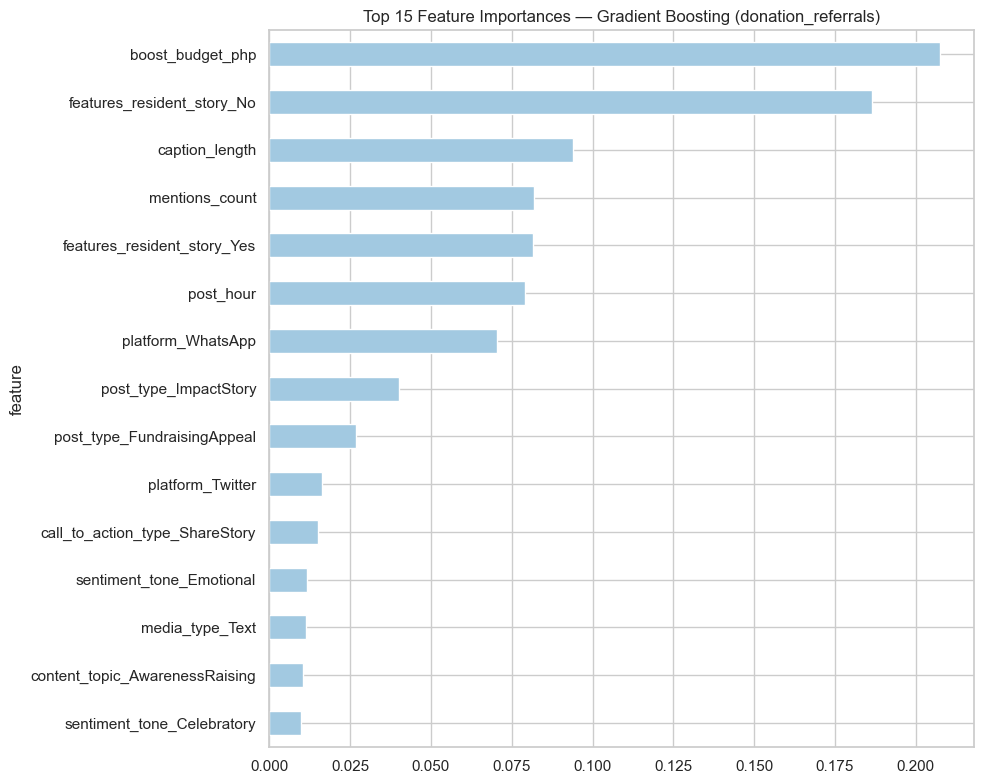

In [8]:
from functions import feature_importance_report

# Feature importances for donation_referrals model
if hasattr(tuned_model_dr, 'feature_importances_'):
    imp = feature_importance_report(tuned_model_dr, feature_names)
    
    fig, ax = plt.subplots(figsize=(10, 8))
    imp.head(15).plot.barh(x='feature', y='importance', ax=ax, color='#A2C9E1', legend=False)
    ax.set_title(f'Top 15 Feature Importances — {best_name_dr} (donation_referrals)')
    ax.invert_yaxis()
    plt.tight_layout()
    plt.show()
else:
    print('Model does not have feature_importances_ attribute (linear model)')

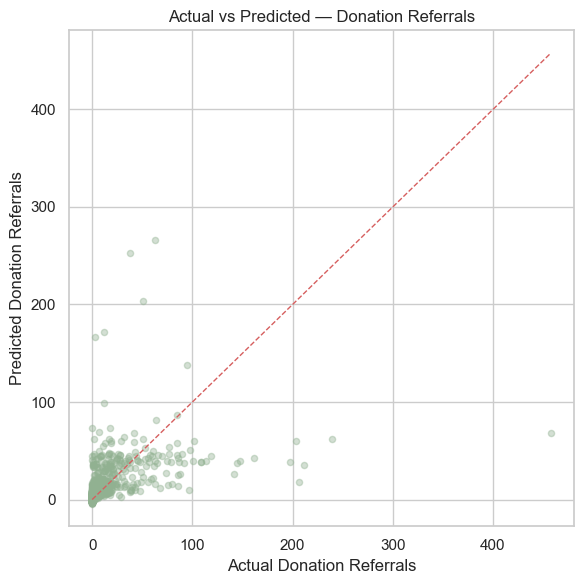

In [9]:
# Actual vs Predicted scatter for donation_referrals
from sklearn.model_selection import cross_val_predict

y_pred_dr = cross_val_predict(tuned_model_dr, X_encoded, y_dr, cv=5)

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(y_dr, y_pred_dr, alpha=0.4, color='#91B191', s=20)
ax.plot([0, y_dr.max()], [0, y_dr.max()], 'r--', lw=1)
ax.set_xlabel('Actual Donation Referrals')
ax.set_ylabel('Predicted Donation Referrals')
ax.set_title('Actual vs Predicted — Donation Referrals')
plt.tight_layout()
plt.show()

## 7. Lookup Table Generation

Instead of running the model in real-time, we pre-compute predictions for all realistic combinations of controllable features. This lookup table is stored as `social_post_predictions.csv`.

- Uses observed categorical combinations from historical data (no synthetic combos)
- Crosses with 25th/50th/75th percentile values for numeric features
- Capped at 50,000 rows for performance

In [10]:
from pipelines.social_media_referrals import run

lookup_df, trained_models = run(posts)

print(f'\nLookup table shape: {lookup_df.shape}')
print(f'\nPredicted columns:')
pred_cols = [c for c in lookup_df.columns if c.startswith('predicted_')]
lookup_df[pred_cols].describe().round(2)

Pipeline 2: Social Media Referrals (6 Targets)
Posts loaded: 812
Encoded features: 56

  ── Target: donation_referrals ──
  Ridge: RMSE=27.4053 MAE=14.6418 R²=0.2297
  Lasso: RMSE=27.1999 MAE=14.1390 R²=0.2436
  Random Forest: RMSE=27.2223 MAE=11.6942 R²=0.2123
  Gradient Boosting: RMSE=26.7897 MAE=12.0930 R²=0.2542
  XGBoost: RMSE=29.5363 MAE=12.7642 R²=0.0009
  LightGBM: RMSE=27.0780 MAE=12.8321 R²=0.2358
  Tuned Gradient Boosting: {'learning_rate': 0.05, 'n_estimators': 100}
  Best model: Gradient Boosting

  ── Target: estimated_donation_value_php ──
  Ridge: RMSE=117101.1179 MAE=51747.4669 R²=0.1273
  Lasso: RMSE=117194.8256 MAE=51933.9856 R²=0.1251
  Random Forest: RMSE=117746.1321 MAE=42390.4327 R²=0.0181
  Gradient Boosting: RMSE=123886.2531 MAE=45169.8953 R²=-0.0977
  XGBoost: RMSE=140822.2645 MAE=48077.7350 R²=-0.8522
  LightGBM: RMSE=117456.7387 MAE=46215.6378 R²=0.0837
  Best model: Ridge

  ── Target: forwards ──
  Ridge: RMSE=76.1121 MAE=27.4087 R²=-0.0183
  Lasso: RMSE=7

,predicted_donation_referrals,predicted_estimated_donation_value_php,predicted_forwards,predicted_profile_visits,predicted_engagement_rate,predicted_impressions
count,43794.00,43794.00,43794.00,43794.00,43794.00,43794.00
mean,11.74,41249.71,9.96,115.32,0.11,4923.13
std,14.36,50127.26,33.21,68.68,0.04,3392.43
min,0.00,0.00,0.00,0.00,0.02,0.00
25%,1.95,0.00,0.00,72.26,0.08,2288.87
50%,5.23,20969.94,0.08,103.02,0.11,4403.33
75%,14.33,61233.46,0.36,136.95,0.14,7253.49
max,72.22,232848.09,257.50,508.19,0.24,17481.06


## 8. Deployment — CSV Output & Web Integration (Ch. 15)

The lookup CSV is consumed by:
- **Backend**: `CsvPredictionService` loads it into memory. `POST /api/predictions/ml/social-lookup` filters by platform, postType, mediaType, etc. and returns the closest matching predictions.
- **Frontend**: The Social Media Editor page sends debounced requests as the user changes post attributes, displaying predicted donation referrals, engagement rate, impressions, etc. in real-time prediction cards.

**Nightly refresh**: `run_all_pipelines.py` regenerates the lookup table at 2:00 AM.

In [11]:
# Sample of the final output
display_cols = ['platform', 'post_type', 'media_type', 'content_topic'] + pred_cols
lookup_df[display_cols].head(10)

,platform,post_type,media_type,content_topic,predicted_donation_referrals,predicted_estimated_donation_value_php,predicted_forwards,predicted_profile_visits,predicted_engagement_rate,predicted_impressions
0,WhatsApp,FundraisingAppeal,Text,Education,5.4985,0.0000,12.0899,34.5481,0.0964,0.0000
1,WhatsApp,FundraisingAppeal,Text,Education,11.4172,0.0000,24.2752,35.9838,0.1013,181.1311
2,WhatsApp,FundraisingAppeal,Text,Education,12.0749,8411.6439,47.7149,45.7850,0.1245,1181.0669
3,WhatsApp,FundraisingAppeal,Text,Education,5.4985,0.0000,1.1458,34.5481,0.0949,0.0000
4,WhatsApp,FundraisingAppeal,Text,Education,11.4172,6429.4709,13.3311,35.9838,0.0998,373.7591
5,WhatsApp,FundraisingAppeal,Text,Education,12.0749,15060.6721,37.1854,45.7850,0.1230,1373.6950
6,WhatsApp,FundraisingAppeal,Text,Education,5.4985,0.0000,12.0899,47.0801,0.0964,0.0000
7,WhatsApp,FundraisingAppeal,Text,Education,11.4172,0.0000,24.2752,55.8818,0.1013,313.6903
8,WhatsApp,FundraisingAppeal,Text,Education,12.0749,5304.5880,47.7149,65.6830,0.1245,1313.6261
9,WhatsApp,FundraisingAppeal,Text,Education,5.4985,0.0000,1.1458,47.0801,0.0949,0.0000


---

### Summary

| Target | Best Model | Key Finding |
|--------|-----------|-------------|
| donation_referrals | GBM | Platform and CTA type most important |
| estimated_donation_value_php | Ridge | Linear relationship with boost budget |
| forwards | LightGBM | Media type (Video/Reel) drives shares |
| profile_visits | GBM | Content topic matters most |
| engagement_rate | GBM | Sentiment tone influences engagement |
| impressions | Ridge | Boosted posts dominate impressions |

All 6 models are deployed as a single lookup CSV powering the Social Media Editor.